# Online Retail Analytics — Exploratory Data Analysis

**Context:** A UK-based online retailer sells gifts and homewares to individual customers and wholesalers across 38 countries. The management team wants to understand revenue drivers, customer behavior, and product performance to guide their commercial strategy.

**Dataset:** [UCI Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail) — 541,909 transactions from Dec 2010 to Dec 2011.

**Business Questions:**
1. What is the total revenue, and how does it trend over time?
2. Which products generate the most revenue?
3. Which countries perform best outside the UK?
4. What share of revenue comes from top customers?
5. What does the customer purchase frequency look like?
6. Are there seasonal patterns in sales?

---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import duckdb

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

%matplotlib inline

In [2]:
# Load the raw dataset
# Download from: https://archive.ics.uci.edu/dataset/352/online+retail
# Place 'Online Retail.xlsx' in data/raw/

df_raw = pd.read_excel('../01_data/raw/Online Retail.xlsx')
print(f'Raw dataset: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns')
df_raw.head()

Raw dataset: 541,909 rows, 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
## 2. Data Exploration

In [3]:
# Data types and non-null counts
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [4]:
# Descriptive statistics
df_raw.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [5]:
# Missing values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
pd.DataFrame({'missing': missing, 'pct': missing_pct}).query('missing > 0')

,missing,pct
Description,1454,0.3
CustomerID,135080,24.9


In [6]:
# Quick look at potential issues
print(f"Negative quantities (returns/cancellations): {(df_raw['Quantity'] < 0).sum():,}")
print(f"Zero or negative unit prices: {(df_raw['UnitPrice'] <= 0).sum():,}")
print(f"Invoices starting with 'C' (cancellations): {df_raw['InvoiceNo'].astype(str).str.startswith('C').sum():,}")
print(f"Unique customers (excl. NaN): {df_raw['CustomerID'].dropna().nunique():,}")
print(f"Unique products: {df_raw['StockCode'].nunique():,}")
print(f"Countries: {df_raw['Country'].nunique()}")

Negative quantities (returns/cancellations): 10,624
Zero or negative unit prices: 2,517
Invoices starting with 'C' (cancellations): 9,288
Unique customers (excl. NaN): 4,372
Unique products: 4,070
Countries: 38


---
## 3. Data Cleaning

**Rules applied:**
- Remove rows where `CustomerID` is missing (can't analyze customer behavior without it)
- Remove cancelled orders (InvoiceNo starting with 'C')
- Remove rows where `Quantity <= 0` or `UnitPrice <= 0`
- Remove duplicates

In [7]:
df = df_raw.copy()
initial_rows = len(df)

# 1. Drop rows without CustomerID
df = df.dropna(subset=['CustomerID'])
print(f'After dropping null CustomerID: {len(df):,} rows ({initial_rows - len(df):,} removed)')

# 2. Remove cancellations
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f'After removing cancellations: {len(df):,} rows')

# 3. Keep only positive quantities and prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f'After removing non-positive qty/price: {len(df):,} rows')

# 4. Remove duplicates
df = df.drop_duplicates()
print(f'After removing duplicates: {len(df):,} rows')

# Summary
removed = initial_rows - len(df)
print(f'\nTotal removed: {removed:,} rows ({removed/initial_rows*100:.1f}%)')
print(f'Clean dataset: {len(df):,} rows')

After dropping null CustomerID: 406,829 rows (135,080 removed)
After removing cancellations: 397,924 rows
After removing non-positive qty/price: 397,884 rows
After removing duplicates: 392,692 rows

Total removed: 149,217 rows (27.5%)
Clean dataset: 392,692 rows


---
## 4. Feature Engineering

In [8]:
# Revenue per line item
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Date components
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

# CustomerID as integer
df['CustomerID'] = df['CustomerID'].astype(int)

print(f'Features added: Revenue, Year, Month, YearMonth, DayOfWeek, Hour')
df.head()

Features added: Revenue, Year, Month, YearMonth, DayOfWeek, Hour


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,YearMonth,DayOfWeek,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,2010-12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,2010-12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,2010-12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,2010-12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,2010-12,Wednesday,8


In [9]:
# Export cleaned dataset
df.to_csv('../01_data/cleaned/online_retail_cleaned.csv', index=False)
df.to_csv('../05_outputs/cleaned_online_retail.csv', index=False)
print(f'Exported {len(df):,} rows to data/cleaned/ and outputs/')

Exported 392,692 rows to data/cleaned/ and outputs/


---
## 5. SQL Analysis with DuckDB

Using DuckDB to run SQL queries directly on the pandas DataFrame — no database setup needed.

In [10]:
con = duckdb.connect()
con.register('retail', df)

### Q1 — Revenue KPIs

In [11]:
kpis = con.execute("""
    SELECT
        ROUND(SUM(Revenue), 2)               AS total_revenue,
        COUNT(DISTINCT InvoiceNo)             AS total_orders,
        COUNT(DISTINCT CustomerID)            AS total_customers,
        COUNT(DISTINCT StockCode)             AS total_products,
        ROUND(SUM(Revenue) / COUNT(DISTINCT InvoiceNo), 2)   AS avg_order_value,
        ROUND(SUM(Revenue) / COUNT(DISTINCT CustomerID), 2)  AS revenue_per_customer
    FROM retail
""").df()

kpis

,total_revenue,total_orders,total_customers,total_products,avg_order_value,revenue_per_customer
0,8887208.89,18532,4338,3665,479.56,2048.69


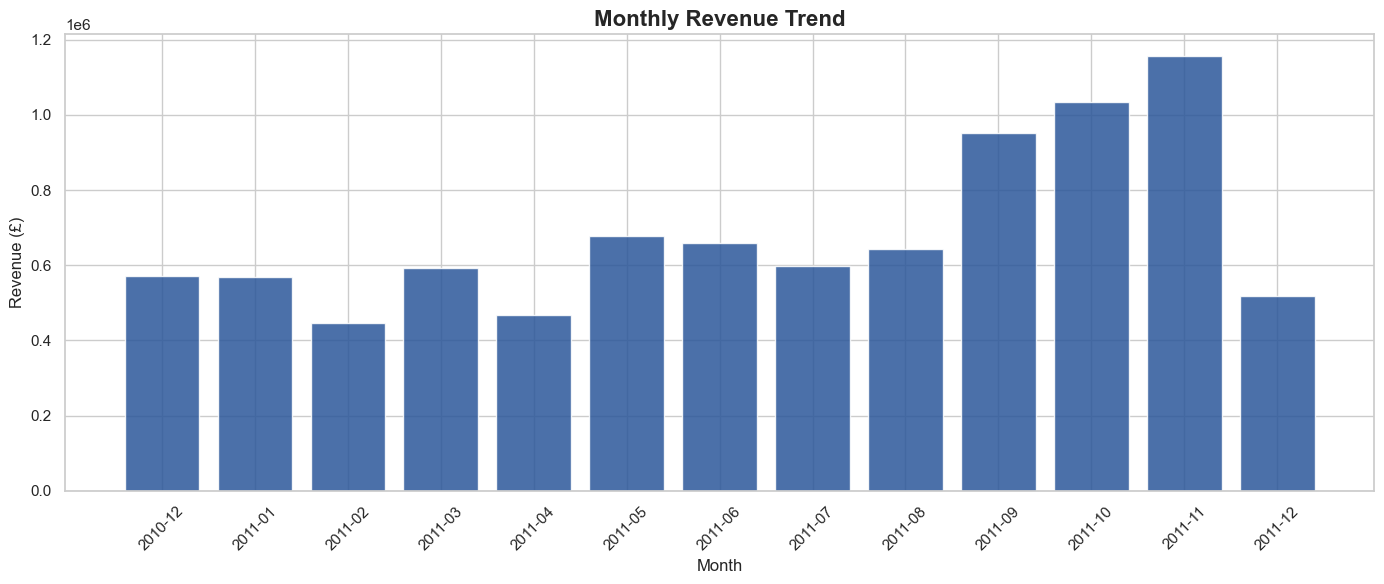

In [12]:
# Monthly revenue trend
monthly_rev = con.execute("""
    SELECT
        YearMonth,
        ROUND(SUM(Revenue), 2)       AS revenue,
        COUNT(DISTINCT InvoiceNo)    AS orders,
        COUNT(DISTINCT CustomerID)   AS customers
    FROM retail
    GROUP BY YearMonth
    ORDER BY YearMonth
""").df()

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(monthly_rev['YearMonth'], monthly_rev['revenue'], color='#2B579A', alpha=0.85)
ax.set_title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../04_dashboard/screenshots/monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### Q2 — Top Products by Revenue

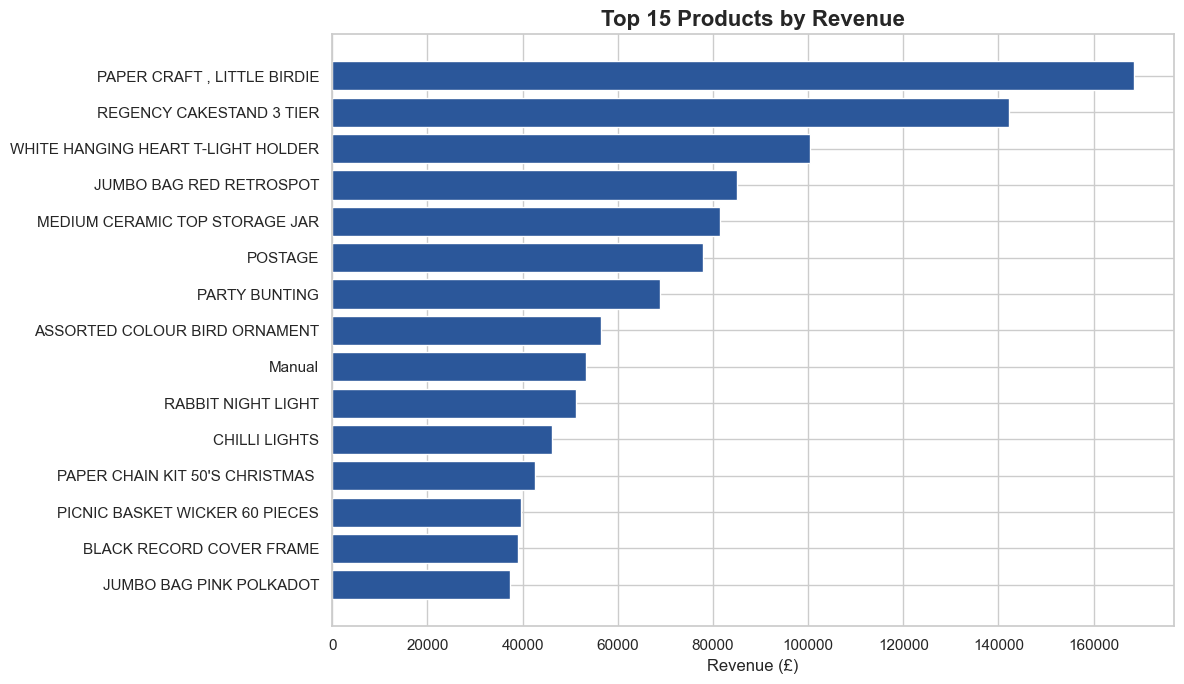

In [13]:
top_products = con.execute("""
    SELECT
        StockCode,
        Description,
        SUM(Quantity)              AS total_qty,
        ROUND(SUM(Revenue), 2)    AS total_revenue,
        COUNT(DISTINCT InvoiceNo) AS order_count
    FROM retail
    GROUP BY StockCode, Description
    ORDER BY total_revenue DESC
    LIMIT 15
""").df()

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top_products['Description'][::-1], top_products['total_revenue'][::-1], color='#2B579A')
ax.set_title('Top 15 Products by Revenue', fontsize=16, fontweight='bold')
ax.set_xlabel('Revenue (£)')
plt.tight_layout()
plt.savefig('../04_dashboard/screenshots/top_products.png', dpi=150, bbox_inches='tight')
plt.show()

### Q3 — Country Performance (excl. UK)

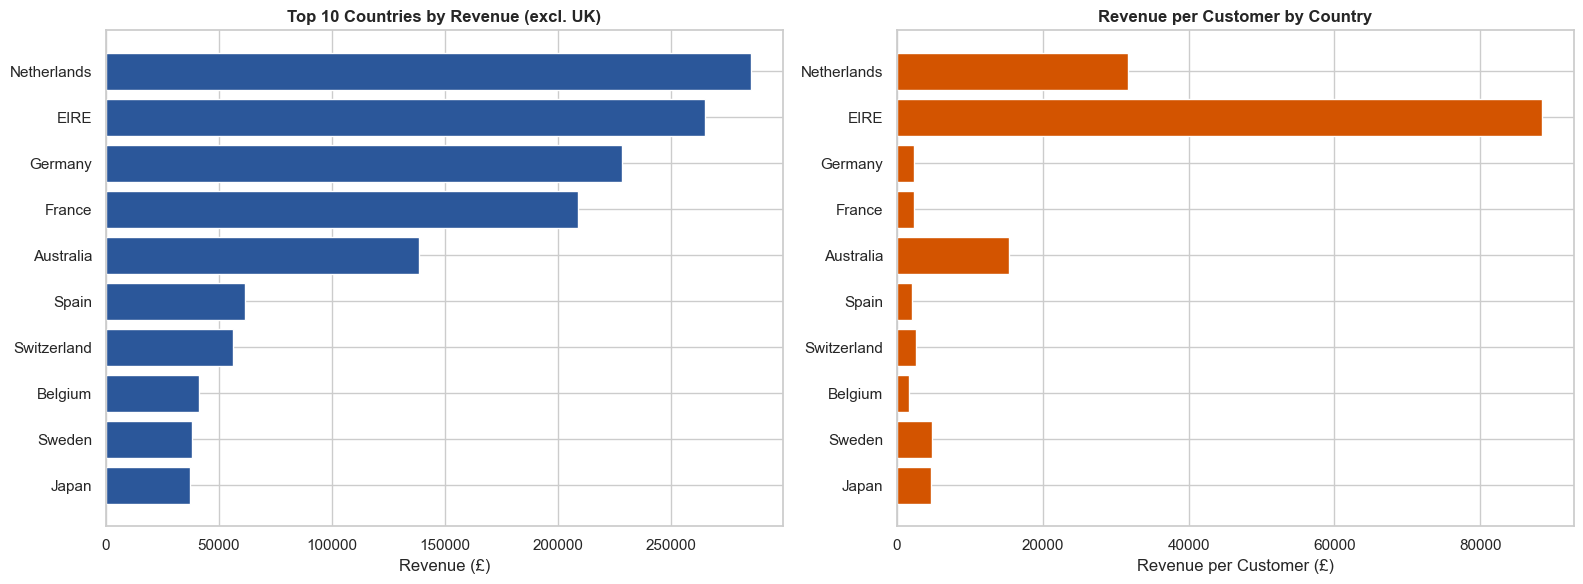

In [14]:
countries = con.execute("""
    SELECT
        Country,
        ROUND(SUM(Revenue), 2)       AS total_revenue,
        COUNT(DISTINCT CustomerID)   AS customers,
        COUNT(DISTINCT InvoiceNo)    AS orders,
        ROUND(SUM(Revenue) / COUNT(DISTINCT CustomerID), 2) AS rev_per_customer
    FROM retail
    WHERE Country != 'United Kingdom'
    GROUP BY Country
    ORDER BY total_revenue DESC
    LIMIT 10
""").df()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(countries['Country'][::-1], countries['total_revenue'][::-1], color='#2B579A')
axes[0].set_title('Top 10 Countries by Revenue (excl. UK)', fontweight='bold')
axes[0].set_xlabel('Revenue (£)')

axes[1].barh(countries['Country'][::-1], countries['rev_per_customer'][::-1], color='#D35400')
axes[1].set_title('Revenue per Customer by Country', fontweight='bold')
axes[1].set_xlabel('Revenue per Customer (£)')

plt.tight_layout()
plt.savefig('../04_dashboard/screenshots/country_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Q4 — Customer Revenue Concentration

In [15]:
customer_rev = con.execute("""
    SELECT
        CustomerID,
        ROUND(SUM(Revenue), 2)        AS total_revenue,
        COUNT(DISTINCT InvoiceNo)     AS total_orders,
        MIN(InvoiceDate)              AS first_purchase,
        MAX(InvoiceDate)              AS last_purchase
    FROM retail
    GROUP BY CustomerID
    ORDER BY total_revenue DESC
""").df()

# Revenue concentration: top 10% of customers
total_rev = customer_rev['total_revenue'].sum()
top_10_pct = customer_rev.head(int(len(customer_rev) * 0.1))['total_revenue'].sum()
top_20_pct = customer_rev.head(int(len(customer_rev) * 0.2))['total_revenue'].sum()

print(f'Total customers: {len(customer_rev):,}')
print(f'Top 10% of customers generate {top_10_pct/total_rev*100:.1f}% of revenue')
print(f'Top 20% of customers generate {top_20_pct/total_rev*100:.1f}% of revenue')

Total customers: 4,338
Top 10% of customers generate 61.4% of revenue
Top 20% of customers generate 74.7% of revenue


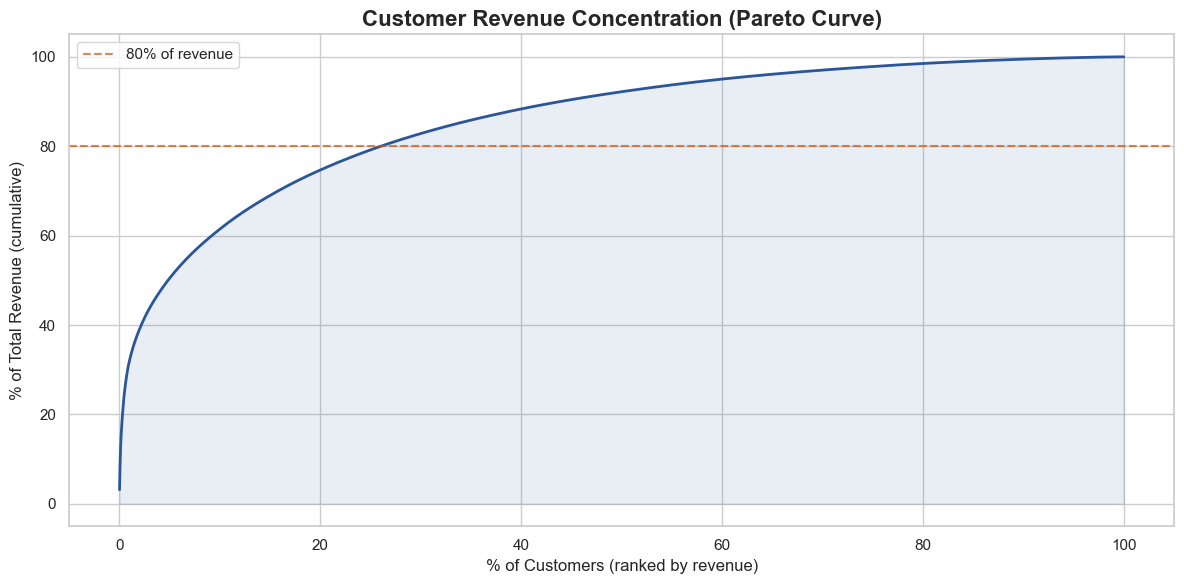

In [16]:
# Cumulative revenue curve
customer_rev_sorted = customer_rev.sort_values('total_revenue', ascending=False).reset_index(drop=True)
customer_rev_sorted['cumulative_rev'] = customer_rev_sorted['total_revenue'].cumsum()
customer_rev_sorted['cumulative_pct'] = customer_rev_sorted['cumulative_rev'] / total_rev * 100
customer_rev_sorted['customer_pct'] = (customer_rev_sorted.index + 1) / len(customer_rev_sorted) * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(customer_rev_sorted['customer_pct'], customer_rev_sorted['cumulative_pct'], color='#2B579A', linewidth=2)
ax.axhline(y=80, color='#D35400', linestyle='--', alpha=0.7, label='80% of revenue')
ax.fill_between(customer_rev_sorted['customer_pct'], customer_rev_sorted['cumulative_pct'], alpha=0.1, color='#2B579A')
ax.set_title('Customer Revenue Concentration (Pareto Curve)', fontsize=16, fontweight='bold')
ax.set_xlabel('% of Customers (ranked by revenue)')
ax.set_ylabel('% of Total Revenue (cumulative)')
ax.legend()
plt.tight_layout()
plt.savefig('../04_dashboard/screenshots/customer_concentration.png', dpi=150, bbox_inches='tight')
plt.show()

### Q5 — Purchase Frequency

In [17]:
frequency = con.execute("""
    SELECT
        order_count,
        COUNT(*) AS num_customers
    FROM (
        SELECT
            CustomerID,
            COUNT(DISTINCT InvoiceNo) AS order_count
        FROM retail
        GROUP BY CustomerID
    ) sub
    GROUP BY order_count
    ORDER BY order_count
""").df()

# Single vs repeat buyers
single = frequency.query('order_count == 1')['num_customers'].sum()
repeat = frequency.query('order_count > 1')['num_customers'].sum()
total_cust = single + repeat

print(f'One-time buyers: {single:,} ({single/total_cust*100:.1f}%)')
print(f'Repeat buyers: {repeat:,} ({repeat/total_cust*100:.1f}%)')

One-time buyers: 1,493 (34.4%)
Repeat buyers: 2,845 (65.6%)


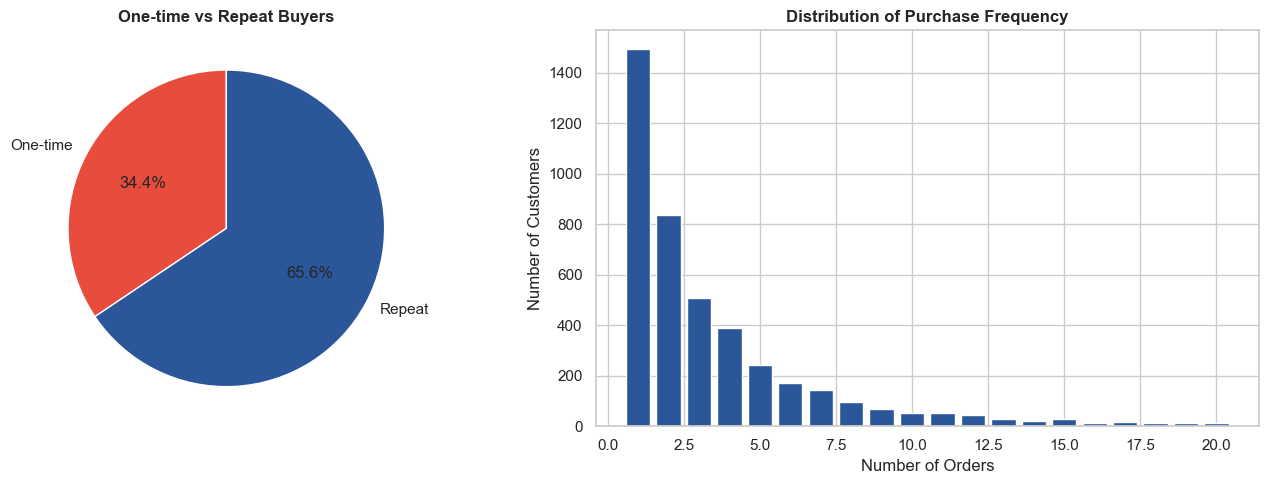

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart: single vs repeat
axes[0].pie([single, repeat], labels=['One-time', 'Repeat'], autopct='%1.1f%%',
            colors=['#E74C3C', '#2B579A'], startangle=90)
axes[0].set_title('One-time vs Repeat Buyers', fontweight='bold')

# Distribution of order counts (capped at 20 for readability)
freq_capped = frequency.query('order_count <= 20')
axes[1].bar(freq_capped['order_count'], freq_capped['num_customers'], color='#2B579A')
axes[1].set_title('Distribution of Purchase Frequency', fontweight='bold')
axes[1].set_xlabel('Number of Orders')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig('../04_dashboard/screenshots/purchase_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

### Q6 — Seasonality Patterns

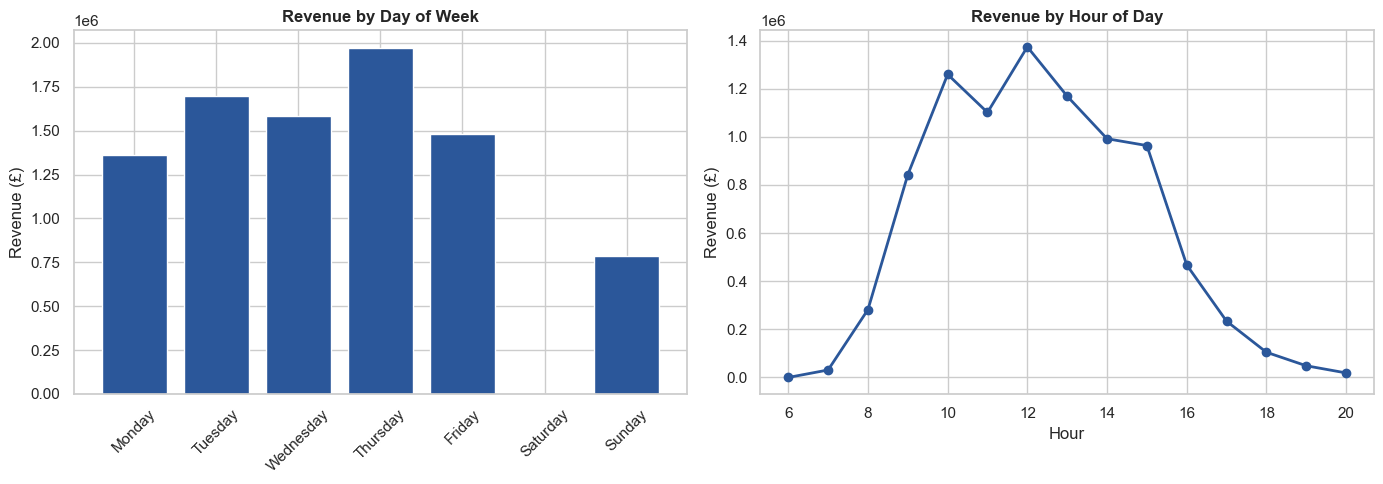

In [19]:
seasonality = con.execute("""
    SELECT
        DayOfWeek,
        Hour,
        ROUND(SUM(Revenue), 2)       AS revenue,
        COUNT(DISTINCT InvoiceNo)    AS orders
    FROM retail
    GROUP BY DayOfWeek, Hour
    ORDER BY Hour
""").df()

# Revenue by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = (
    seasonality.groupby('DayOfWeek')
    .agg({'revenue': 'sum', 'orders': 'sum'})
    .reindex(day_order)
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(daily.index, daily['revenue'], color='#2B579A')
axes[0].set_title('Revenue by Day of Week', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=45)

# Revenue by hour
hourly = seasonality.groupby('Hour').agg({'revenue': 'sum'}).reset_index()
axes[1].plot(hourly['Hour'], hourly['revenue'], marker='o', color='#2B579A', linewidth=2)
axes[1].set_title('Revenue by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Revenue (£)')

plt.tight_layout()
plt.savefig('../04_dashboard/screenshots/seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary of Findings

| Question | Finding |
|---|---|
| Total revenue | **£8,887,208.89** over the 12-month period |
| Revenue trend | Revenue generally increased through the year and **peaked in November 2011**; **February 2011** was the weakest month, while **December 2011 appears lower because it is a partial month** |
| Top products | Revenue is concentrated among a small number of products, led by **PAPER CRAFT, LITTLE BIRDIE**, **REGENCY CAKESTAND 3 TIER**, and **WHITE HANGING HEART T-LIGHT HOLDER** |
| Top countries (excl. UK) | The strongest international markets by revenue are **Netherlands, EIRE, and Germany** |
| Customer concentration | The **top 10% of customers generate 61.4% of revenue**; the **top 20% generate 74.7%** |
| Repeat buyers | **65.6% of customers are repeat buyers** |
| Seasonality | The highest revenue day is **Thursday**, and the peak revenue hour is **12:00** |

## Recommendations

1. **Prioritize retention of high-value customers**, since a small share of customers drives most of the revenue.
2. **Focus commercial efforts on the best-performing international markets** outside the UK, especially Netherlands, EIRE, and Germany.
3. **Monitor product concentration risk** and support top-performing SKUs with pricing, stock planning, and promotional visibility.
4. **Plan campaigns and operations around peak demand periods**, especially around the strongest weekdays and midday peak sales hours.

In [20]:
# Cleanup
con.close()
print('Analysis complete.')

Analysis complete.
